# Synthetic Dasein: Embodied AI and the Metabolic Cost of Masking
**Modeling Heideggerian Phenomenology via Dual-Process Neural Architectures**

## 1. Abstract
Traditional AI models intelligence as a disembodied, continuously deliberative process. However, phenomenologists like Heidegger and Dreyfus argue that true intelligence is "Being-in-the-world"—primarily relying on fast, unconscious reflexes (Ready-to-Hand) and only shifting to conscious, heavy deliberation (Present-at-Hand) when a breakdown occurs.

This simulation models a **Dual-Process Agent** (*Synthetic Dasein*) to explore the energy economics of learning and social masking.

## 2. The Architecture
The agent is composed of two competing systems:
1. **The Graph Mind (Present-at-Hand):** Represents conscious deliberation. It uses shortest-path algorithms on a knowledge graph to find perfect solutions, but at a massive metabolic cost.
2. **The Reflex Mind (Ready-to-Hand):** Represents muscle memory / SNNs. It is incredibly fast and energy-efficient. It learns via Dopamine-modulated Hebbian plasticity, trained by the Graph Mind.

## 3. Experimental Design
* **Experiment 1 (The Heideggerian Drop):** Demonstrates the transition from conscious deliberation to reflex. As the Reflex Mind gains confidence via reinforcement, the agent "drops" into a Ready-to-Hand state, resulting in a massive reduction in metabolic cost.
* **Experiment 2 (Social Friction & Masking):** Introduces a social environment with strict rules (e.g., "Library Zones"). We apply an $\alpha$ coefficient (Social Anxiety/Masking) that forces the agent to doubt its own reflexes. The results quantify the hidden metabolic cost of "masking" in high-friction social processing compared to a neurotypical baseline.

Episode 0: Energy Cost = 1800
Episode 10: Energy Cost = 90
Episode 20: Energy Cost = 90
Episode 30: Energy Cost = 90
Episode 40: Energy Cost = 90


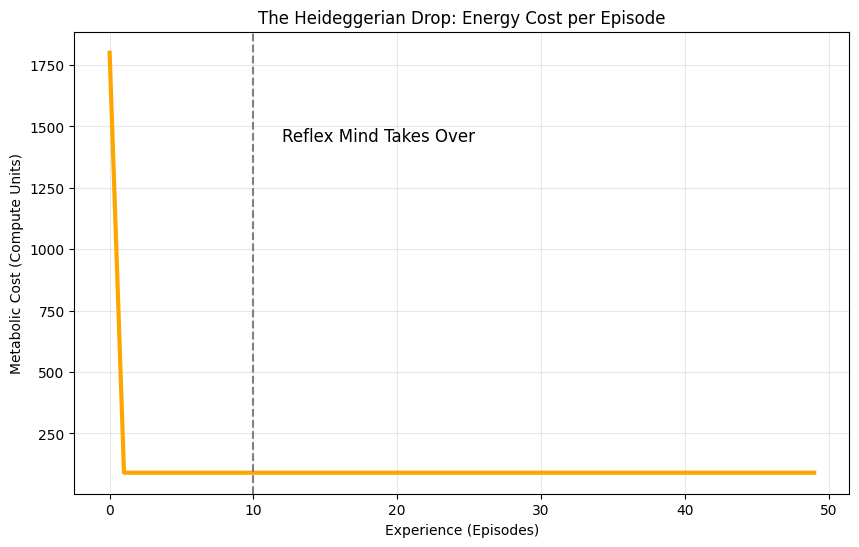

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. The Environment (The "World")
# ==========================================
class GridWorld:
    def __init__(self, size=10):
        self.size = size
        self.graph = nx.grid_2d_graph(size, size)
        self.start = (0, 0)
        self.goal = (size-1, size-1)
        # Add some "obstacles" by removing nodes
        obstacles = [(1,1), (2,2), (3,3), (5,5)]
        for node in obstacles:
            if node in self.graph: self.graph.remove_node(node)

    def get_reward(self, position):
        return 1.0 if position == self.goal else -0.01  # Small penalty for time

# ==========================================
# 2. The Graph Mind (Present-at-Hand)
# ==========================================
class GraphMind:
    """
    Represents Conscious Deliberation.
    Perfect accuracy, massive compute cost.
    """
    def __init__(self, world_graph, goal):
        self.world_map = world_graph
        self.goal = goal
        self.base_energy_cost = 100  # Arbitrary high metabolic unit

    def plan_step(self, current_pos):
        # Heavy Compute: Re-calculating shortest path every single step
        try:
            path = nx.shortest_path(self.world_map, source=current_pos, target=self.goal)
            # Return next step and high energy cost
            next_node = path[1] if len(path) > 1 else current_pos
            return next_node, self.base_energy_cost
        except:
            return current_pos, self.base_energy_cost

# ==========================================
# 3. The Reflex Mind (Ready-to-Hand)
# ==========================================
class ReflexMind:
    """
    Represents the SNN / Muscle Memory.
    Fast, low energy, learns via Dopamine (STDP).
    """
    def __init__(self, world_size):
        # Simplified SNN Weights: Map (State) -> (Action probabilities)
        # In a real SNN, these would be synaptic weights between neurons
        self.weights = np.random.rand(world_size, world_size, 4) * 0.01
        self.base_energy_cost = 5  # Very low metabolic unit

    def get_action(self, current_pos):
        # Fast forward pass (Matrix mult)
        x, y = current_pos
        action_probs = self.weights[x, y]
        confidence = np.max(action_probs)
        action_idx = np.argmax(action_probs)

        # Map index to move (0:up, 1:right, 2:down, 3:left)
        moves = [(0,1), (1,0), (0,-1), (-1,0)]
        proposed_move = moves[action_idx]

        return proposed_move, confidence, self.base_energy_cost

    def update_weights(self, current_pos, successful_move_idx, dopamine_signal):
        # This is the "Synthetic Dopamine" modulation
        # Standard Hebbian Learning: Fire together, wire together
        # Modulated by Dopamine magnitude
        x, y = current_pos
        learning_rate = 0.1

        # Strengthen the successful synaptic connection
        self.weights[x, y, successful_move_idx] += learning_rate * dopamine_signal

        # Normalize to keep stable
        self.weights[x, y] /= np.sum(self.weights[x, y])

# ==========================================
# 4. The Synthetic Dasein (The Agent)
# ==========================================
class SyntheticDasein:
    def __init__(self, world):
        self.world = world
        self.graph_mind = GraphMind(world.graph, world.goal)
        self.reflex_mind = ReflexMind(world.size)

        self.history_energy = []
        self.history_mode = [] # 0 for Graph, 1 for Reflex

    def run_episode(self):
        current_pos = self.world.start
        total_energy = 0
        steps = 0

        while current_pos != self.world.goal and steps < 50:
            # 1. Check Reflex Mind first (Fast path)
            reflex_move, confidence, reflex_cost = self.reflex_mind.get_action(current_pos)

            # THE HEIDEGGERIAN THRESHOLD
            # If confidence is high enough, we "assume the abstraction" (Use SNN)
            # If not, we fall back to "conscious thought" (Use Graph)
            threshold = 0.8

            if confidence > threshold:
                # --- READY-TO-HAND MODE ---
                next_pos = (current_pos[0] + reflex_move[0], current_pos[1] + reflex_move[1])
                used_mode = "Reflex"
                step_cost = reflex_cost
            else:
                # --- PRESENT-AT-HAND MODE ---
                # Graph Mind takes over, calculates perfect move
                target_node, graph_cost = self.graph_mind.plan_step(current_pos)
                next_pos = target_node
                used_mode = "Graph"
                step_cost = graph_cost

                # CRITICAL: We use the Graph's "correct" answer to train the Reflex
                # This is "Supervised Learning" from the "Self"
                # Calculate which move index corresponds to the Graph's choice
                move_diff = (next_pos[0]-current_pos[0], next_pos[1]-current_pos[1])
                moves = [(0,1), (1,0), (0,-1), (-1,0)]
                if move_diff in moves:
                    correct_idx = moves.index(move_diff)

                    # SYNTHETIC DOPAMINE RELEASE
                    # The "Relief" of finding the right path generates dopamine
                    dopamine = 1.0
                    self.reflex_mind.update_weights(current_pos, correct_idx, dopamine)

            # Update State
            total_energy += step_cost
            current_pos = next_pos if next_pos in self.world.graph else current_pos
            steps += 1

        return total_energy

# ==========================================
# 5. Execution & Visualization
# ==========================================

# Initialize
world = GridWorld(size=10)
agent = SyntheticDasein(world)

# Run Simulation
episodes = 50
energy_log = []

for e in range(episodes):
    e_cost = agent.run_episode()
    energy_log.append(e_cost)
    if e % 10 == 0:
        print(f"Episode {e}: Energy Cost = {e_cost}")

# Plotting "The Drop"
plt.figure(figsize=(10,6))
plt.plot(energy_log, linewidth=3, color='orange')
plt.title("The Heideggerian Drop: Energy Cost per Episode")
plt.xlabel("Experience (Episodes)")
plt.ylabel("Metabolic Cost (Compute Units)")
plt.axvline(x=10, linestyle='--', color='grey', label='Transition Point')
plt.text(12, max(energy_log)*0.8, "Reflex Mind Takes Over", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

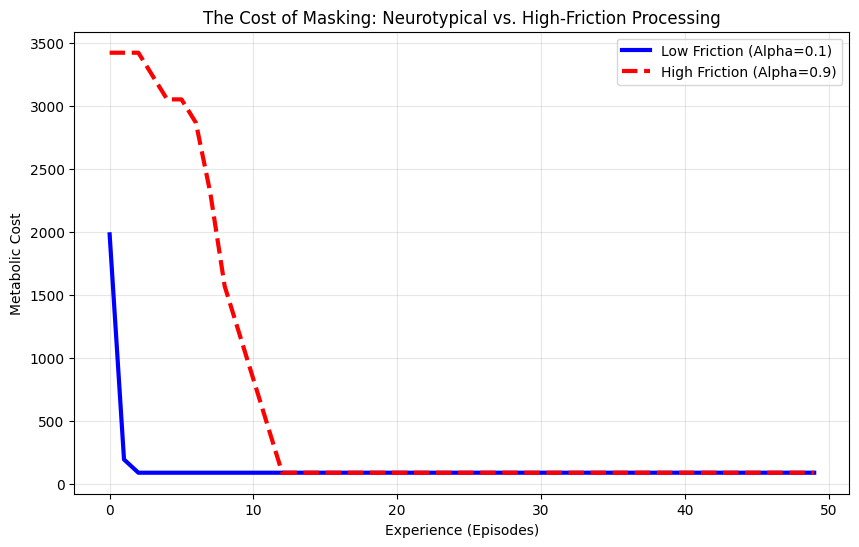

In [ ]:
# ==========================================
# EXPERIMENT 2: SOCIAL FRICTION
# ==========================================

class SocialWorld(GridWorld):
    def __init__(self, size=10):
        super().__init__(size)
        # 1. Define Social Zones (0 = Neutral, 1 = Quiet Zone)
        self.social_map = np.zeros((size, size))
        self.social_map[0:5, 0:5] = 1 # Top-left is a Library (Quiet Zone)

    def get_social_feedback(self, position, action_type):
        # Action Types: 0 = Move Quietly, 1 = Move Loudly (Running)
        zone_type = self.social_map[position]

        # If in Library (Zone 1) and Running (Action 1) -> Social Error
        if zone_type == 1 and action_type == 1:
            return -10.0 # Massive Social Penalty (Embarrassment)
        return 0.0

class SocialAgent(SyntheticDasein):
    def __init__(self, world, alpha=0.0):
        super().__init__(world)
        self.alpha = alpha # Social Anxiety / Masking Coefficient (0.0 to 1.0)

    def run_social_episode(self):
        current_pos = self.world.start
        total_energy = 0
        steps = 0

        while current_pos != self.world.goal and steps < 50:
            # Check Reflex Confidence
            reflex_move, confidence, reflex_cost = self.reflex_mind.get_action(current_pos)

            # === THE MASKING MODIFIER ===
            # High Alpha reduces effective confidence.
            # The agent "doubts" its own reflex because the stakes are high.
            # If Alpha is 0.8, confidence must be HUGE to override the anxiety.
            adjusted_threshold = 0.8 + (self.alpha * 0.15)

            # Also, we artificially inflate the "cost" of the reflex in the agent's mind
            # representing the "worry" about making a social error.

            if confidence > adjusted_threshold:
                # READY-TO-HAND (Risk taken)
                next_pos = (current_pos[0] + reflex_move[0], current_pos[1] + reflex_move[1])
                step_cost = reflex_cost
            else:
                # PRESENT-AT-HAND (Masking/Checking)
                # The agent consults the Graph to be 100% sure of the social rule
                target_node, graph_cost = self.graph_mind.plan_step(current_pos)
                next_pos = target_node

                # Metabolic Cost increases with Alpha
                # "I have to think about my posture, my tone, my eye contact..."
                step_cost = graph_cost * (1 + self.alpha)

                # Train the reflex (Slowly)
                move_diff = (next_pos[0]-current_pos[0], next_pos[1]-current_pos[1])
                moves = [(0,1), (1,0), (0,-1), (-1,0)]
                if move_diff in moves:
                    correct_idx = moves.index(move_diff)
                    # High Alpha agents learn SLOWER because they are risk-averse?
                    # Or maybe they learn faster but refuse to USE it?
                    # Let's keep learning constant, but EXECUTION gated.
                    self.reflex_mind.update_weights(current_pos, correct_idx, 1.0)

            # Update State
            total_energy += step_cost
            current_pos = next_pos if next_pos in self.world.graph else current_pos
            steps += 1

        return total_energy

# ==========================================
# EXECUTION: THE COMPARISON
# ==========================================

# Setup
social_world = SocialWorld(size=10)

# Agent A: Low Friction (Neurotypical / Comfortable) - Alpha = 0.1
agent_nt = SocialAgent(social_world, alpha=0.1)

# Agent B: High Friction (High Masking / Anxious) - Alpha = 0.9
agent_hm = SocialAgent(social_world, alpha=0.9)

log_nt = []
log_hm = []

# Run 50 Episodes
for e in range(50):
    log_nt.append(agent_nt.run_social_episode())
    log_hm.append(agent_hm.run_social_episode())

# Plotting
plt.figure(figsize=(10,6))
plt.plot(log_nt, linewidth=3, color='blue', label='Low Friction (Alpha=0.1)')
plt.plot(log_hm, linewidth=3, color='red', linestyle='--', label='High Friction (Alpha=0.9)')
plt.title("The Cost of Masking: Neurotypical vs. High-Friction Processing")
plt.xlabel("Experience (Episodes)")
plt.ylabel("Metabolic Cost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

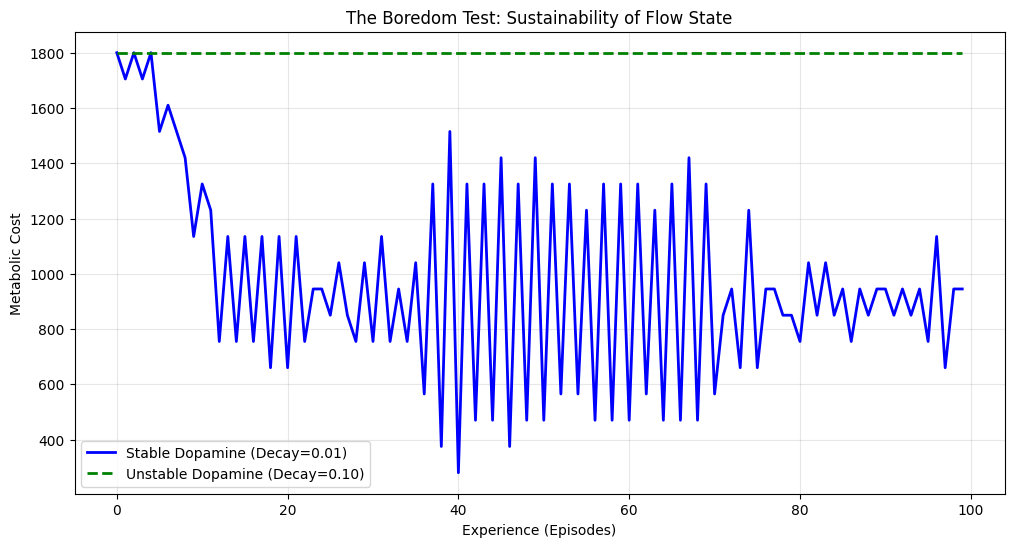

In [ ]:
# ==========================================
# EXPERIMENT 3: THE BOREDOM TEST (ADHD MODEL)
# ==========================================

class DopamineAgent(SyntheticDasein):
    def __init__(self, world, decay_rate=0.0):
        super().__init__(world)
        self.decay_rate = decay_rate # The "Boredom" factor

    def run_temporal_episode(self):
        current_pos = self.world.start
        total_energy = 0
        steps = 0

        while current_pos != self.world.goal and steps < 50:
            # 1. APPLY DECAY (The Entropic Drift)
            # Every step, the SNN forgets a little bit if not reinforced
            self.reflex_mind.weights *= (1.0 - self.decay_rate)

            # Check Reflex
            reflex_move, confidence, reflex_cost = self.reflex_mind.get_action(current_pos)

            threshold = 0.8

            if confidence > threshold:
                # READY-TO-HAND (Flow State)
                next_pos = (current_pos[0] + reflex_move[0], current_pos[1] + reflex_move[1])
                step_cost = reflex_cost

                # CRITICAL: In "Flow", we rarely get massive dopamine spikes unless it's novel.
                # If the task is boring, we might NOT update weights, allowing decay to win.
                # Let's say we only reinforce 10% of the time in Flow State.
                if np.random.rand() < 0.1:
                     move_diff = (next_pos[0]-current_pos[0], next_pos[1]-current_pos[1])
                     moves = [(0,1), (1,0), (0,-1), (-1,0)]
                     if move_diff in moves:
                        self.reflex_mind.update_weights(current_pos, moves.index(move_diff), 0.5)

            else:
                # PRESENT-AT-HAND (Conscious Effort)
                target_node, graph_cost = self.graph_mind.plan_step(current_pos)
                next_pos = target_node
                step_cost = graph_cost

                # We learn heavily when we are consciously trying
                move_diff = (next_pos[0]-current_pos[0], next_pos[1]-current_pos[1])
                moves = [(0,1), (1,0), (0,-1), (-1,0)]
                if move_diff in moves:
                    self.reflex_mind.update_weights(current_pos, moves.index(move_diff), 1.0)

            total_energy += step_cost
            current_pos = next_pos if next_pos in self.world.graph else current_pos
            steps += 1

        return total_energy

# ==========================================
# EXECUTION
# ==========================================

# Setup
world = GridWorld(size=10)

# Agent A: Low Decay (Neurotypical / Sustained Focus)
agent_nt = DopamineAgent(world, decay_rate=0.01)

# Agent B: High Decay (ADHD / Boredom)
# The weights decay 10% every step! Hard to hold onto the "Flow"
agent_adhd = DopamineAgent(world, decay_rate=0.10)

log_nt = []
log_adhd = []

# Run LONG experiment to see long-term stability
for e in range(100):
    log_nt.append(agent_nt.run_temporal_episode())
    log_adhd.append(agent_adhd.run_temporal_episode())

# Plotting
plt.figure(figsize=(12,6))
plt.plot(log_nt, linewidth=2, color='blue', label='Stable Dopamine (Decay=0.01)')
plt.plot(log_adhd, linewidth=2, color='green', linestyle='--', label='Unstable Dopamine (Decay=0.10)')
plt.title("The Boredom Test: Sustainability of Flow State")
plt.xlabel("Experience (Episodes)")
plt.ylabel("Metabolic Cost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()